Stripe only uplink example
----------------------------
This notebook shows how to receive a CP-OFDM signal on the stripe and propagate it towards the central unit. All the radio units receive the signal and propagate it one by one where the furthest unit starts propagating first.

In [13]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plotter import plotter
from sub_THz_stripe.radiostripe.radiostripe import RadioStripe
from sub_THz_stripe.central_unit.central_unit import CentralUnit
from sub_THz_stripe.radio_unit.radio_unit import RadioUnit
from wireless_channel.subTHz_channel import Channel
from wireless_channel.waveforms import Waveform
from sub_THz_stripe.amplifier.amplifier import Amplifier
from sub_THz_stripe.combiner.combiner import Combiner
from sub_THz_stripe.coupler.coupler import Coupler
from sub_THz_stripe.phase_shifter.phase_shifter import PhaseShifter
from sub_THz_stripe.splitter.splitter import Splitter
from sub_THz_stripe.utils import calculate_nmse

In [14]:
environment = "office_space_inline"

# Read out the config file.
config_file = f"environments/{environment}/config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

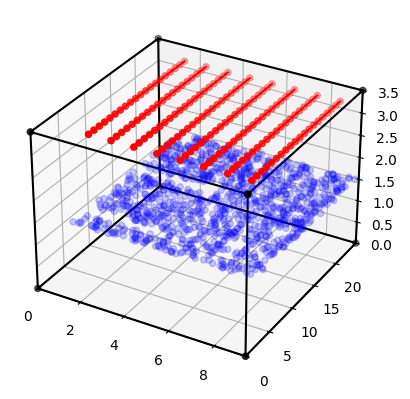

In [15]:
# Plot the room with the strip in it.
plotter.plot_room(config)

In [16]:
# Read out the Waveform config file.
config_file = "environments/waveform_config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    waveform_config = yaml.safe_load(file)

# Construct the waveform class based on the loaded configuration.
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

ue_pos = None
for ue in config["ue_positions"]:
    if ue["x"] == 2.0 and ue["y"] == 21.5 and ue["z"] == 1.5:
        ue_pos = ue
        break

In [17]:
# Read out the Component config file.
config_file = "environments/component_config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    component_config = yaml.safe_load(file)

# Build all the RadioStripe objects based on the configuration.
stripes: list[RadioStripe] = []
for stripe_cfg in config["radio_stripes"]:
    stripes.append(RadioStripe.from_config_locations(stripe_cfg, component_config, config["antenna"]["N_antennas"], wf))

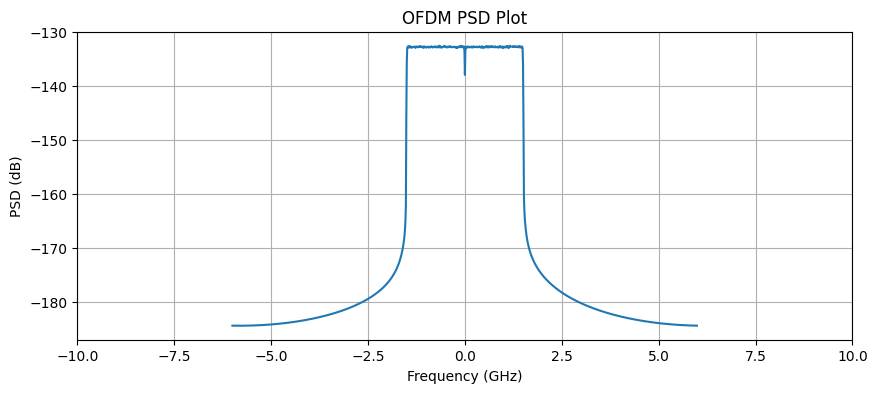

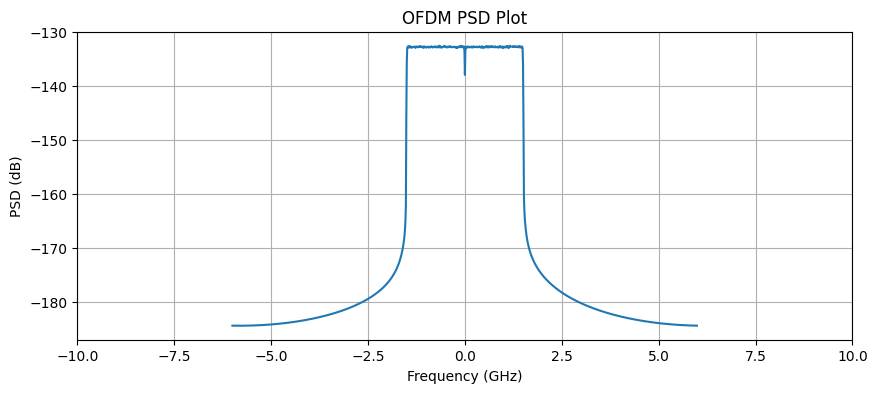

In [18]:
# Generate an CP-OFDM waveform in the time domain.
bits = wf.generate_bits()
qam = wf.qam_modulate()
ofdm_time = wf.ofdm_modulate()  # shape: nr_ofdm_symb x (fftsize + cp length)
wf.plot_psd()

In [19]:
cu = CentralUnit()  # todo are these configs loadable?
ofdm_time_after_cu = cu.run(ofdm_time)  # shape: nr_ofdm_symbols x (fft_size + cp length)

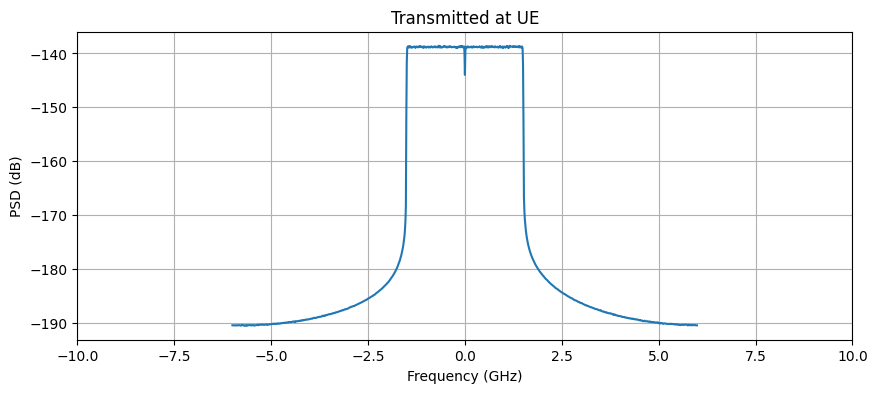

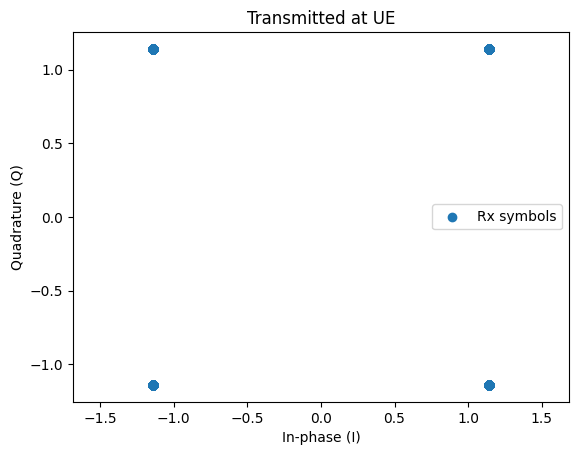

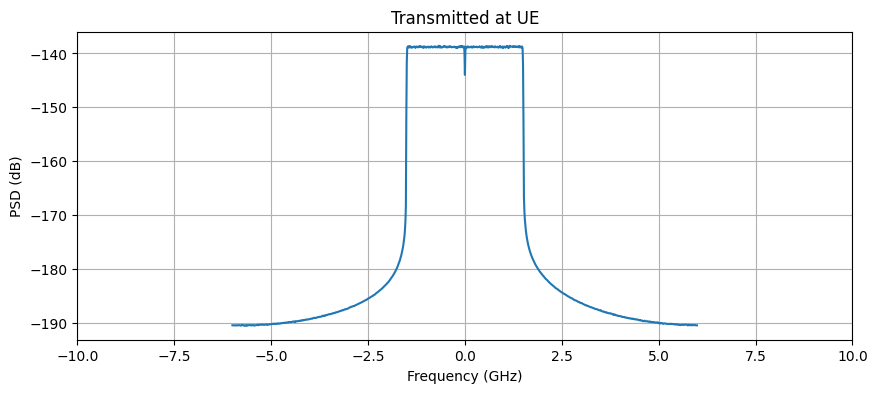

In [ ]:
amp = Amplifier(bw=config["sub_thz"]["bw"])
coup = Coupler(wf=wf)
split = Splitter(config["antenna"]["N_antennas"])
comb = Combiner()
ps = PhaseShifter(num_shifters=config["antenna"]["N_antennas"], resolution=4)
ue_ru = RadioUnit(x=0, y=0, z=0, boost_amp=amp, antenna_amp=amp, coup_in=coup, coup_out=coup, splitter=split, combiner=comb, pshift=ps)

shifts = [0, 0, 0, 0]
iq_data_tx, imdata = ue_ru.transmit(ofdm_time_after_cu, shifts)
# Make an IQ-plot and PSD-plot of the data transmitted at the UE (one antenna).
wf.plot_iq_time(iq_data_tx[0], title="Transmitted at UE")
wf.plot_psd(iq_data_tx[0], title="Transmitted at UE")

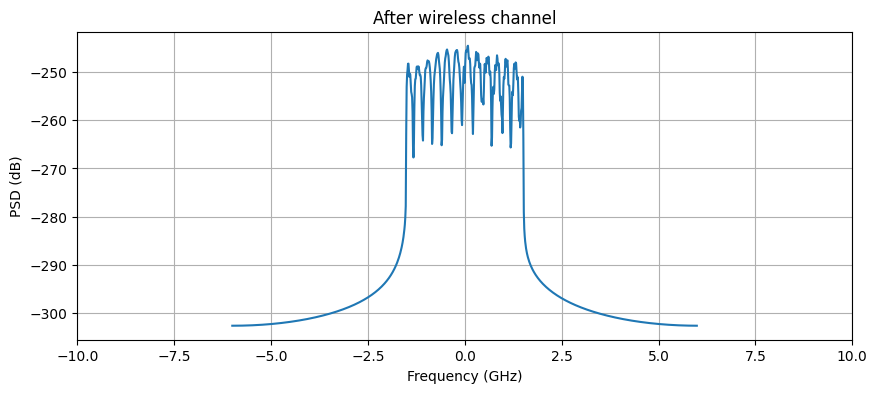

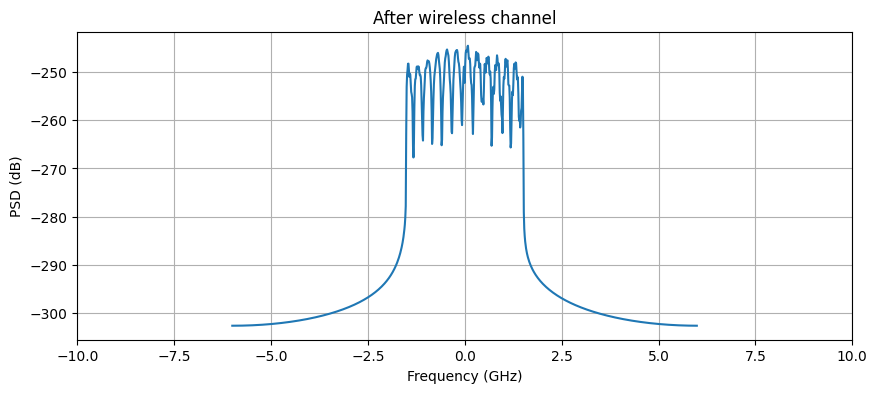

In [21]:
channel = Channel.from_sionna(ue_pos, environment)
iq_data_rus = channel.transmit_ul(iq_data_tx, wf)
wf.plot_psd(iq_data_rus[0][0][0], title="After wireless channel")

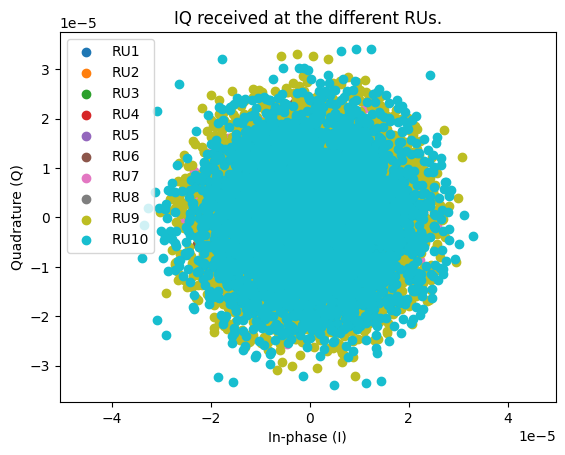

In [22]:
# Plot the received IQ-data for several RUs of the first stripe.
ru_ofdm_freqs = []
for i, ru_data in enumerate(iq_data_rus[0][0:10]):
    ru_ofdm_freqs.append(wf.ofdm_time_to_freq(ru_data[0])[0])

labels = [f"RU{i+1}" for i in range(config["stripe_config"]["N_RUs"])]
fig = plotter.plot_constellation(np.array(ru_ofdm_freqs), labels=labels, title="IQ received at the different RUs.")

UE position: x2.0 y21.5 z1.5
Psig_in utils: -27.813534948948572 dBm
X_time utils: -27.814619610527043 dBm
Psig_in utils: -27.813534948948572 dBm
X_time utils: -27.814619610527043 dBm
Psig_in utils: -27.813534948948572 dBm
X_time utils: -27.814619610527043 dBm
Psig_in utils: -27.813534948948572 dBm
X_time utils: -27.814619610527043 dBm
Psig_in utils: -27.813534948948572 dBm
X_time utils: -27.814619610527043 dBm


Psig_in utils: -32.5732412955094 dBm
X_time utils: -32.57646344988809 dBm
Psig_in utils: -32.5732412955094 dBm
X_time utils: -32.57646344988809 dBm
Psig_in utils: -32.5732412955094 dBm
X_time utils: -32.57646344988809 dBm
Psig_in utils: -32.5732412955094 dBm
X_time utils: -32.57646344988809 dBm
Psig_in utils: -32.5732412955094 dBm
X_time utils: -32.57646344988809 dBm
Psig_in utils: -42.318440181470045 dBm
X_time utils: -42.349546156909675 dBm
Psig_in utils: -42.318440181470045 dBm
X_time utils: -42.349546156909675 dBm
Psig_in utils: -42.318440181470045 dBm
X_time utils: -42.349546156909675 dBm
Psig_in utils: -42.318440181470045 dBm
X_time utils: -42.349546156909675 dBm
Psig_in utils: -42.318440181470045 dBm
X_time utils: -42.349546156909675 dBm
Psig_in utils: -50.41408317066249 dBm
X_time utils: -50.61620449342756 dBm
Psig_in utils: -50.41408317066249 dBm
X_time utils: -50.61620449342756 dBm
Psig_in utils: -50.41408317066249 dBm
X_time utils: -50.61620449342756 dBm
Psig_in utils: -50.4

/home/dramco_spark/6GTandem-simulator/sub_THz_stripe/utils.py:80: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


Psig_in utils: -56.11058185035993 dBm
X_time utils: -56.91992498825637 dBm
Psig_in utils: -56.11058185035993 dBm
X_time utils: -56.91992498825637 dBm
Psig_in utils: -56.11058185035993 dBm
X_time utils: -56.91992498825637 dBm
Psig_in utils: -56.11058185035993 dBm
X_time utils: -56.91992498825637 dBm
Psig_in utils: -56.11058185035993 dBm
X_time utils: -56.91992498825637 dBm
Psig_in utils: -59.5918282989217 dBm
X_time utils: -61.65718267644103 dBm
Psig_in utils: -59.5918282989217 dBm
X_time utils: -61.65718267644103 dBm
Psig_in utils: -59.5918282989217 dBm
X_time utils: -61.65718267644103 dBm
Psig_in utils: -59.5918282989217 dBm
X_time utils: -61.65718267644103 dBm
Psig_in utils: -59.5918282989217 dBm
X_time utils: -61.65718267644103 dBm
Psig_in utils: -61.04758852021912 dBm
X_time utils: -64.34730719552537 dBm
Psig_in utils: -61.04758852021912 dBm
X_time utils: -64.34730719552537 dBm
Psig_in utils: -61.04758852021912 dBm
X_time utils: -64.34730719552537 dBm
Psig_in utils: -61.04758852021

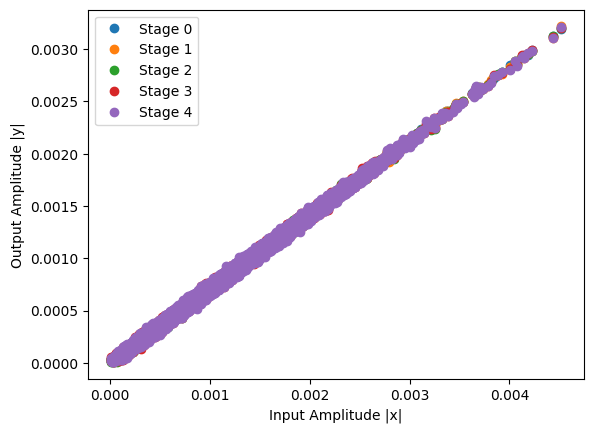

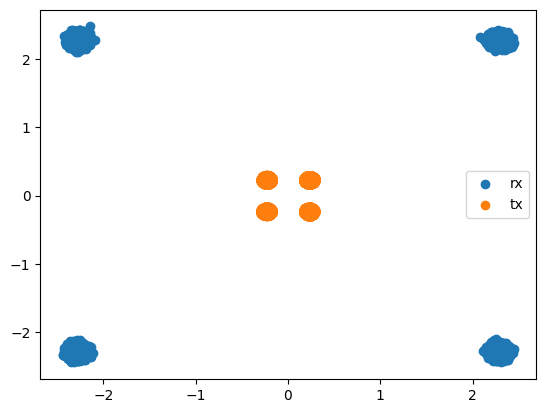

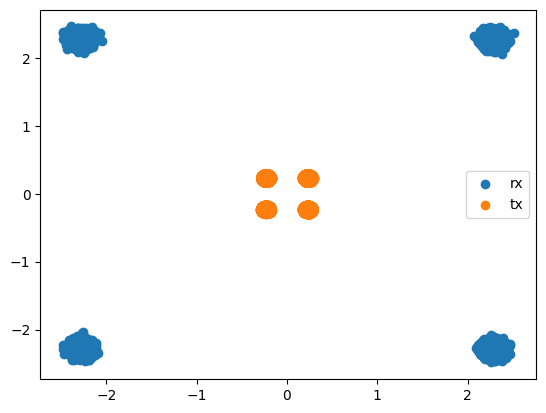

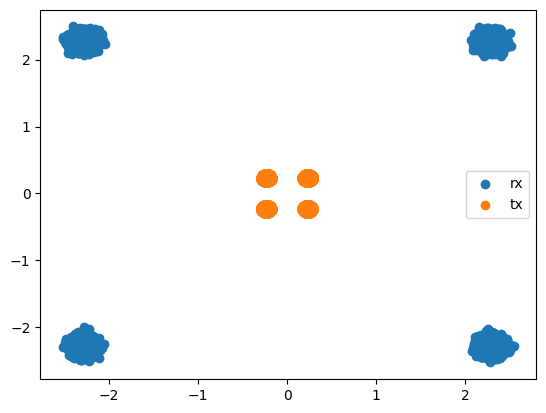

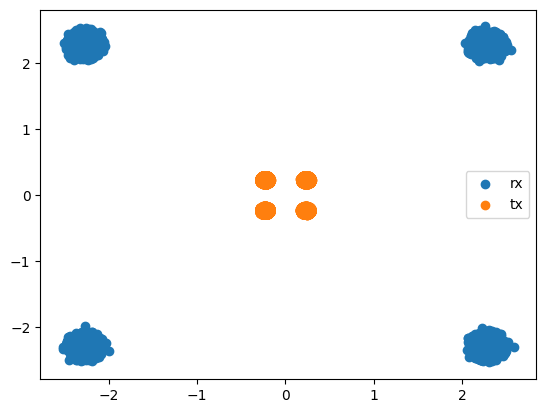

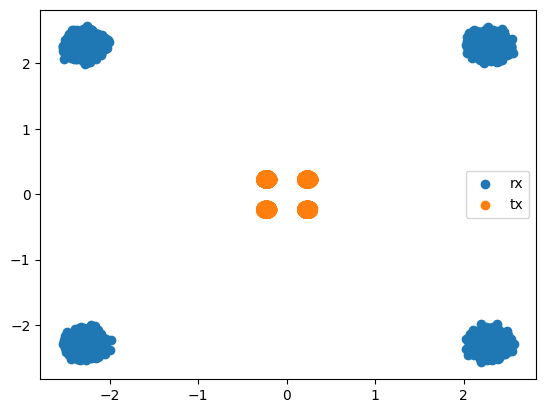

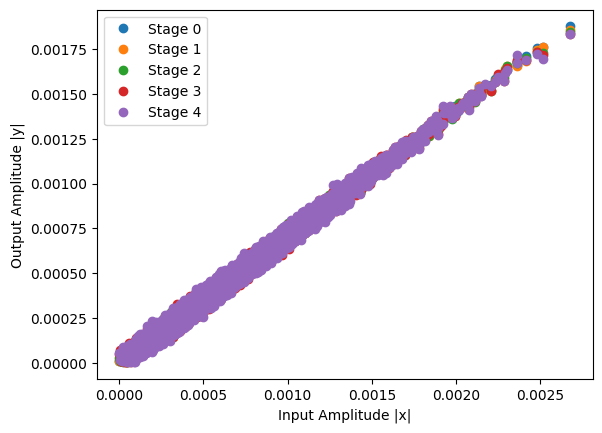

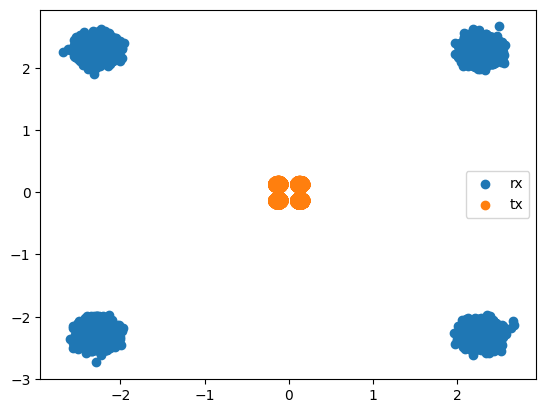

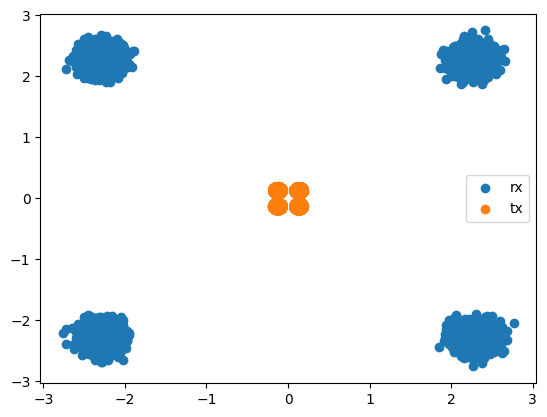

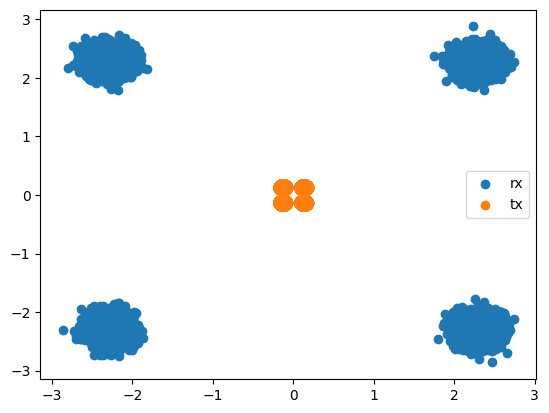

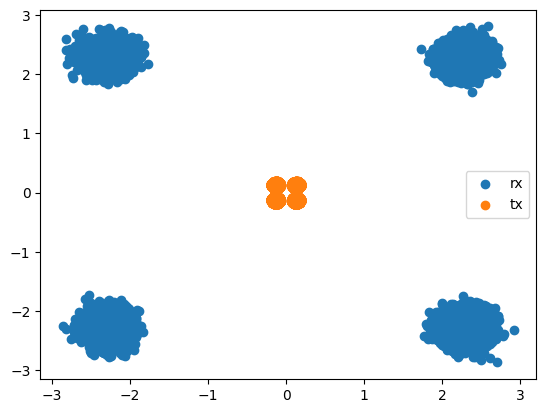

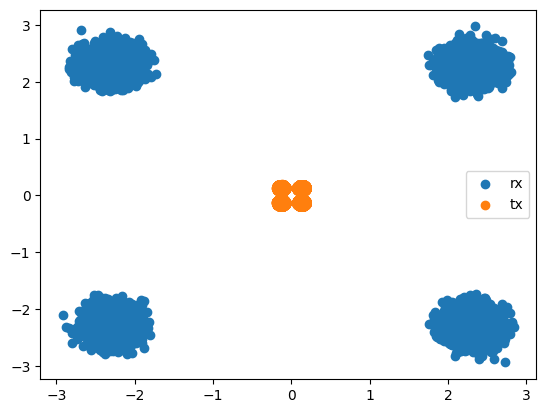

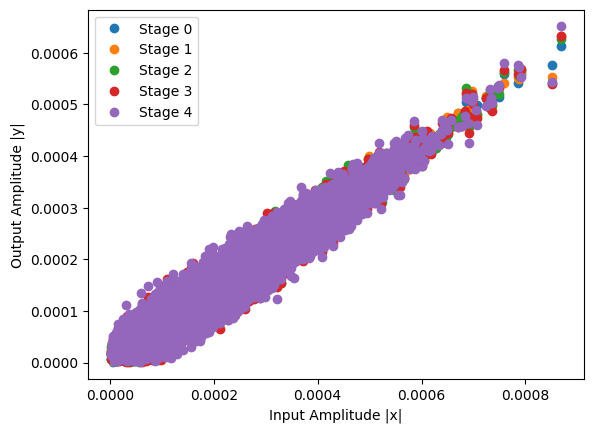

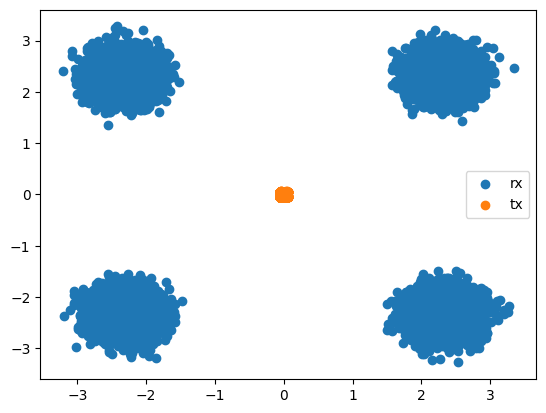

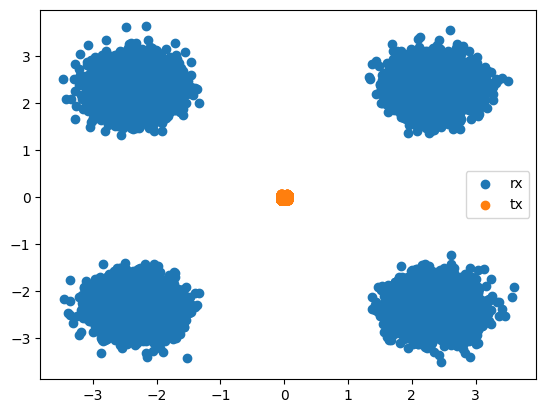

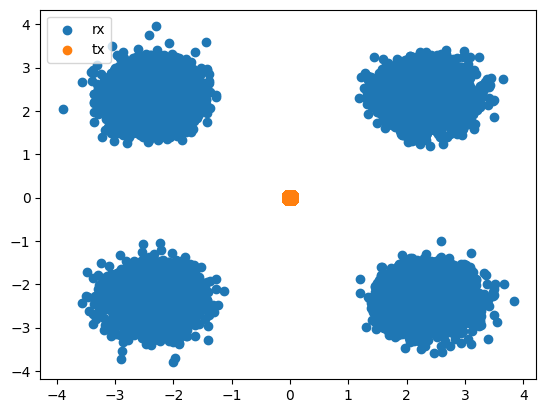

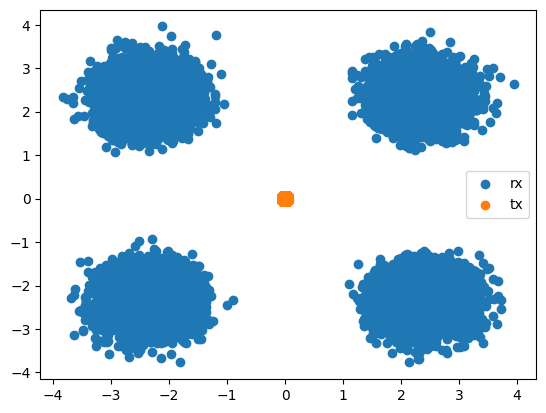

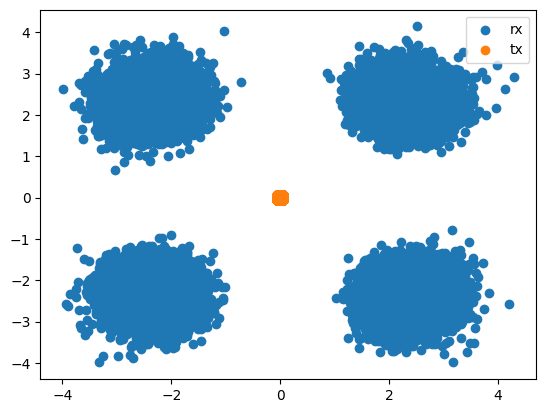

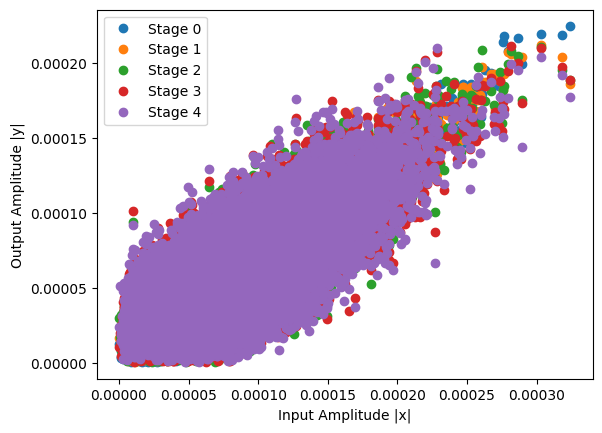

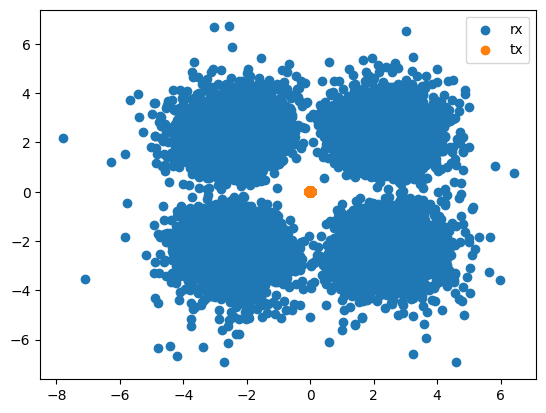

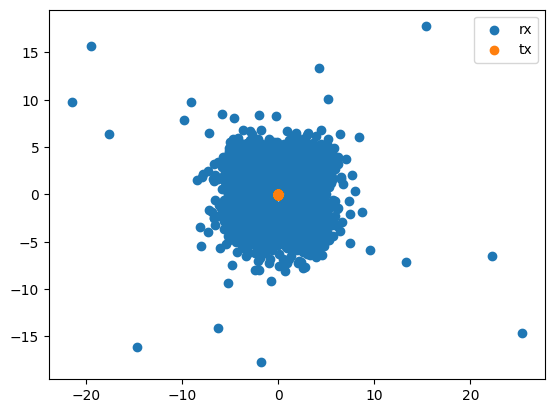

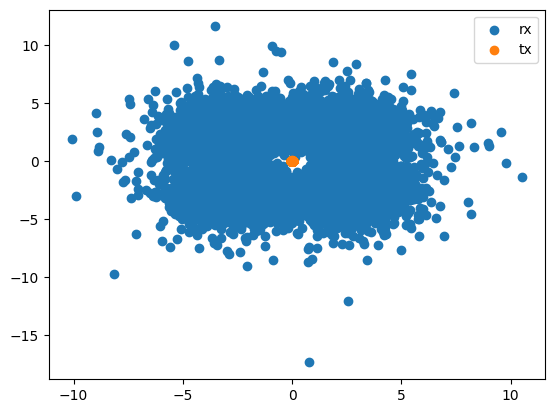

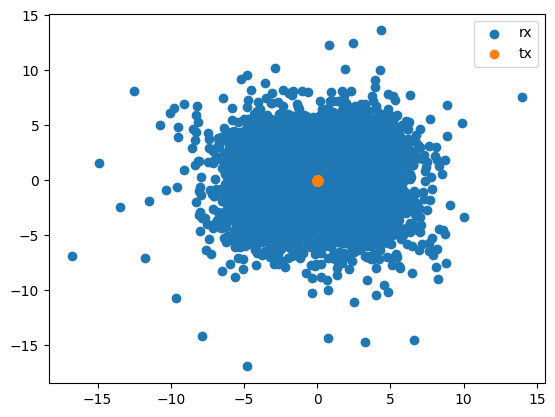

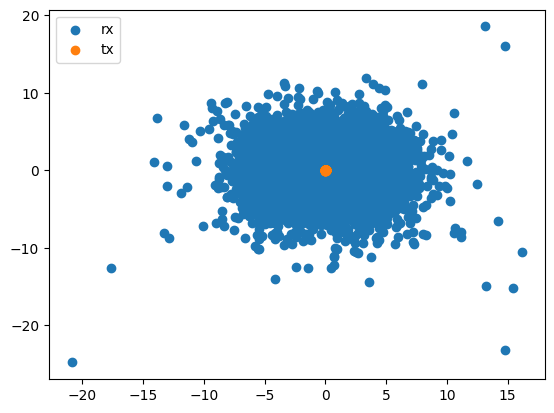

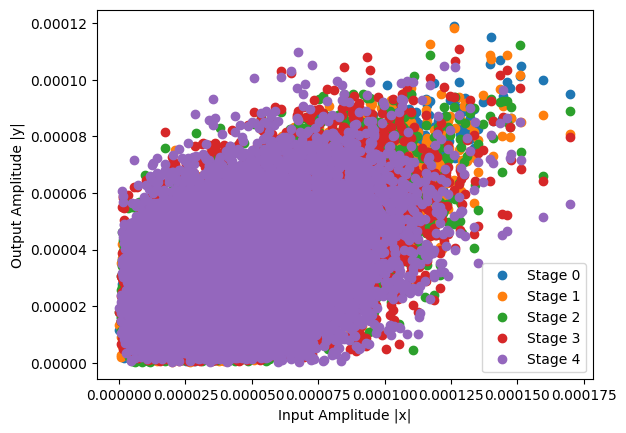

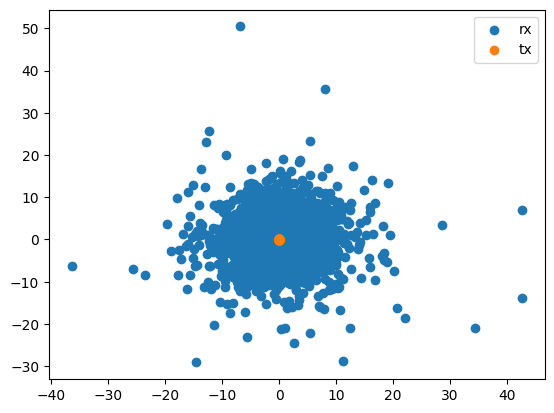

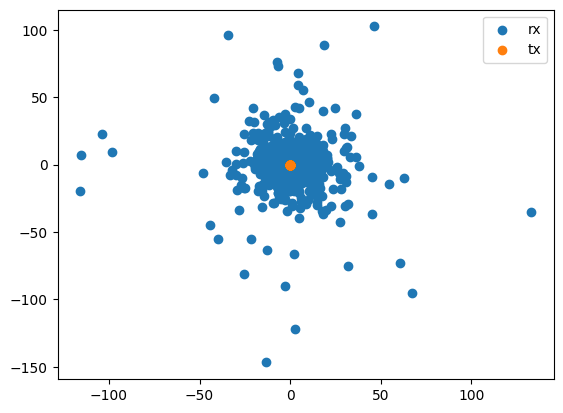

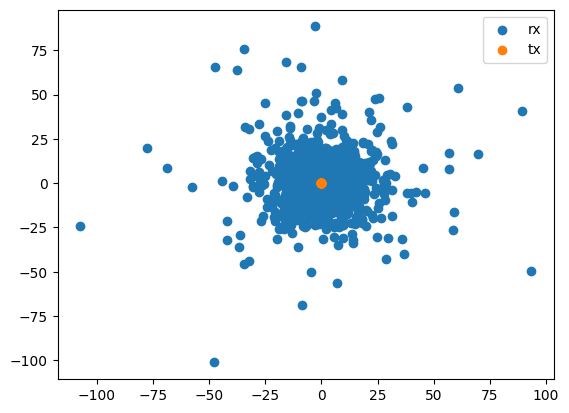

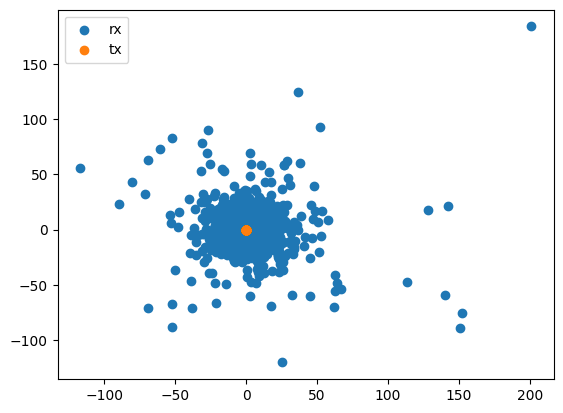

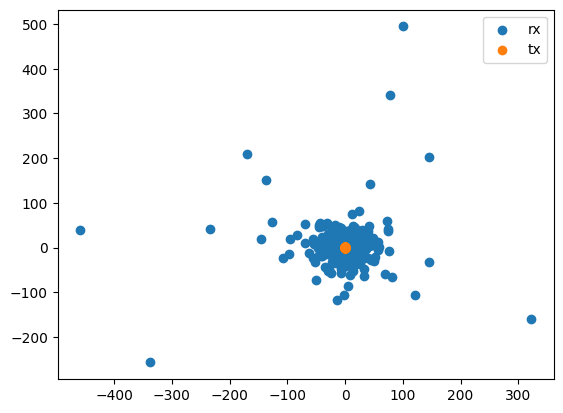

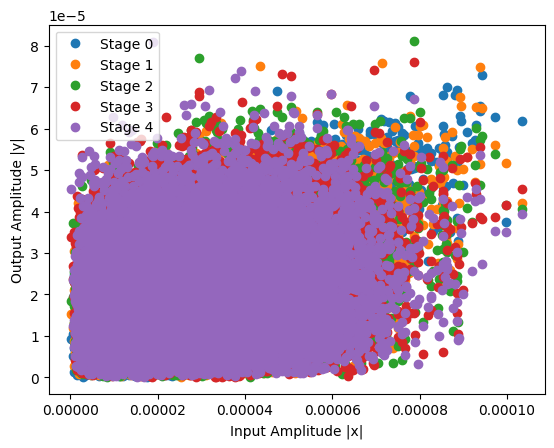

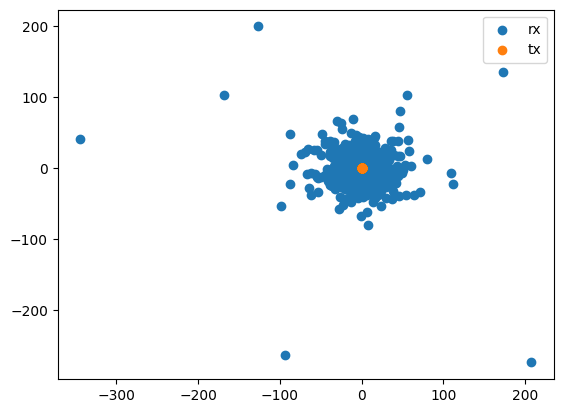

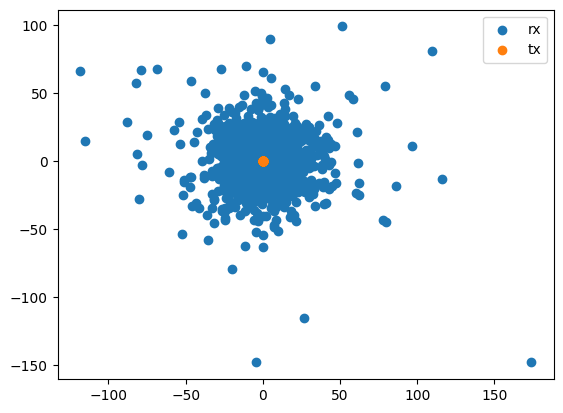

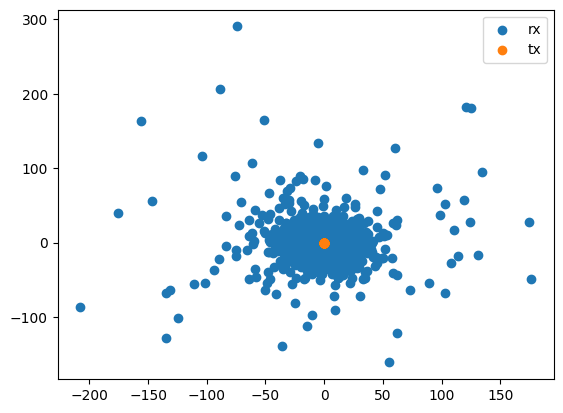

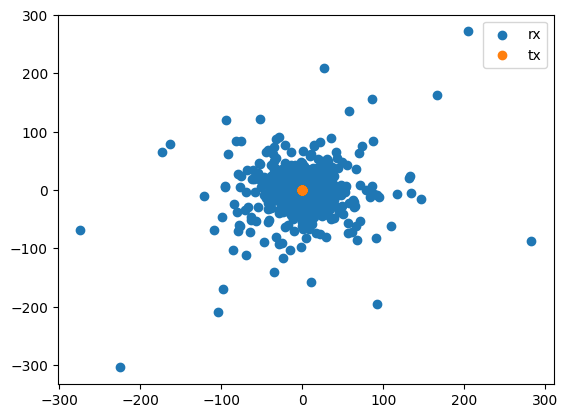

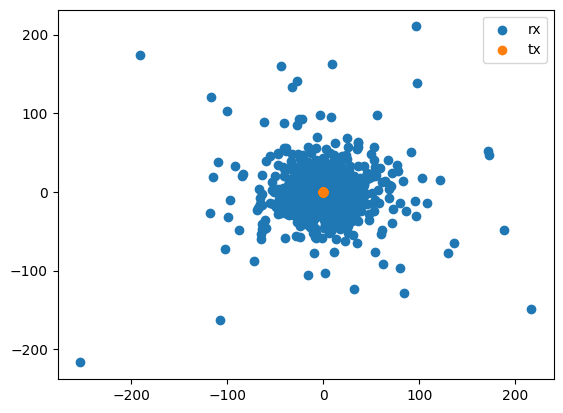

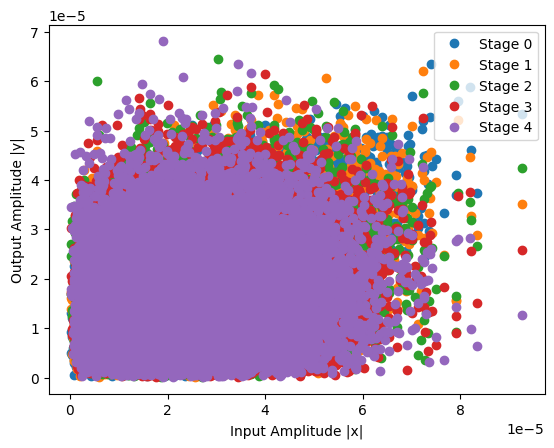

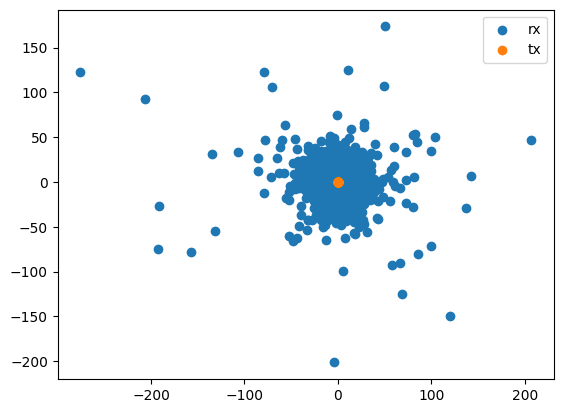

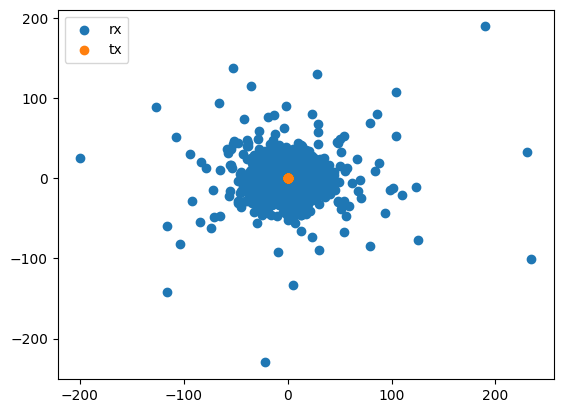

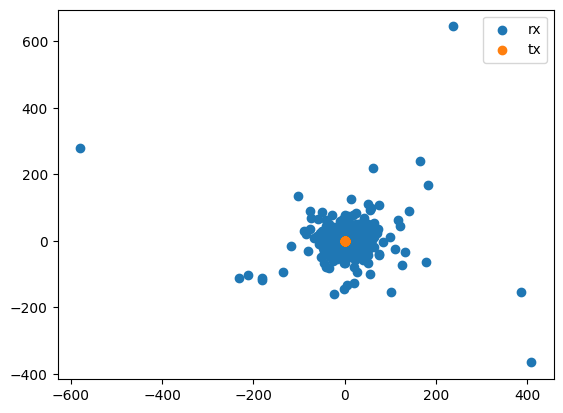

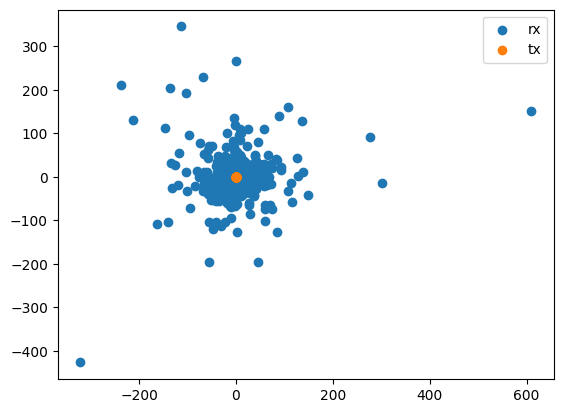

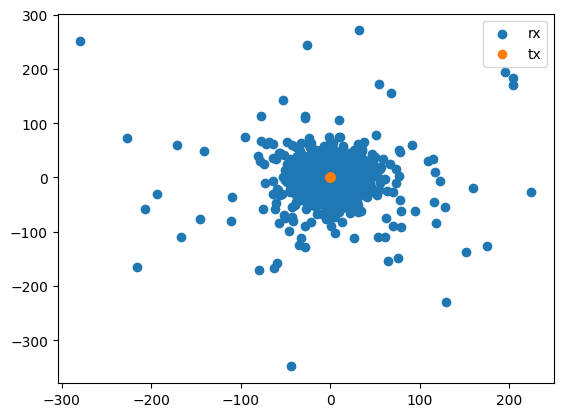

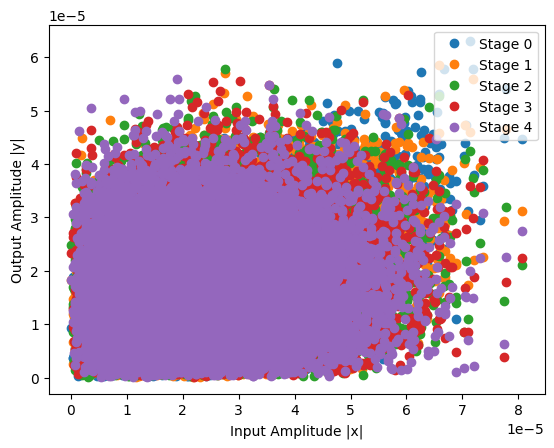

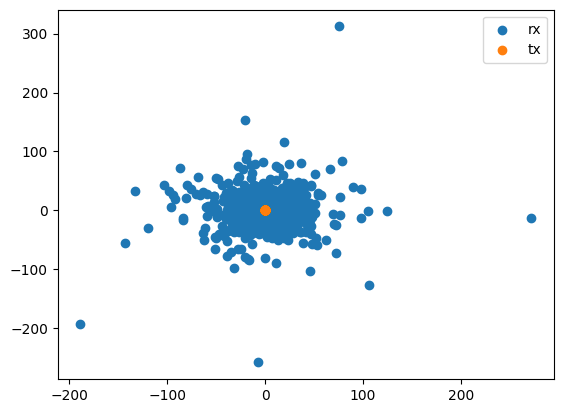

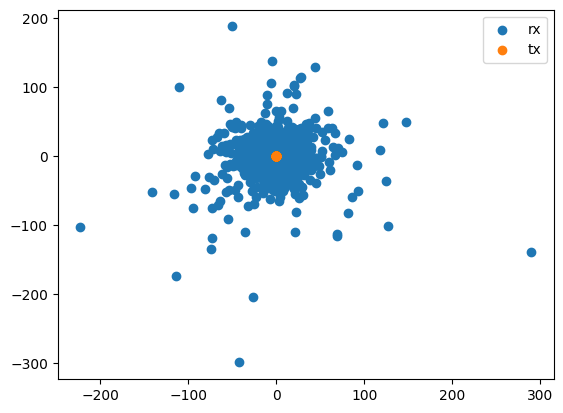

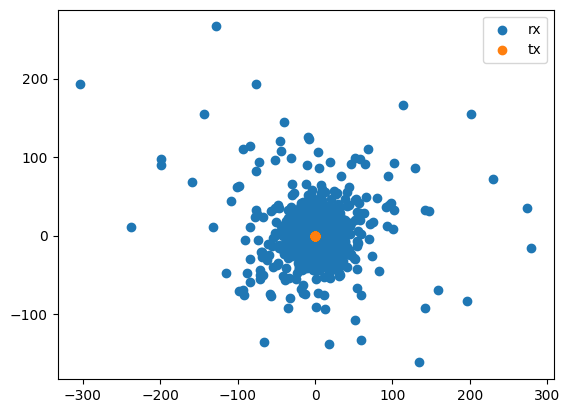

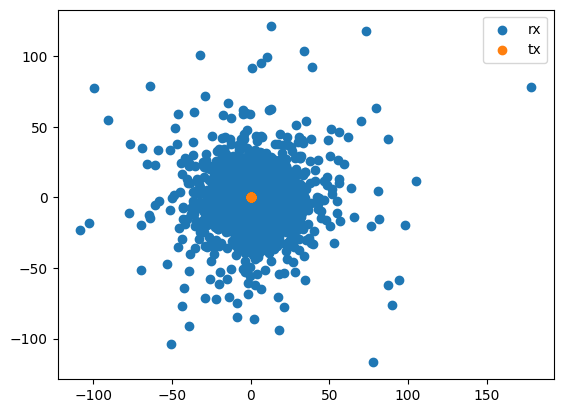

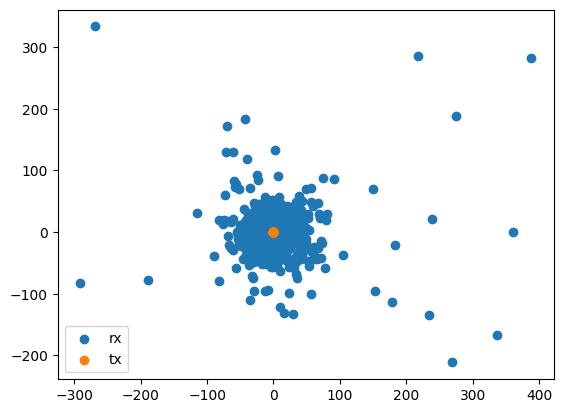

In [23]:
print(f"UE position: x{ue_pos["x"]} y{ue_pos["y"]} z{ue_pos["z"]}")
ru_shift = [0, 0, 0, 0]
stripe_data = []

for stripe_idx, (stripe, data) in enumerate(zip(stripes, iq_data_rus)):
    stripe.active_unit = 19
    y, imdata = stripe.receive(data, ru_shift, False)

    stripe_data.append(y)

    fig, ax = plt.subplots()
    # Make AM/AM plots for the cascaded PAs.
    datax = []
    datay = []
    datas = []
    subcs = []
    for i, (x, y) in enumerate(zip(imdata[6:(4*4)+7:4], imdata[7:(4*4)+8:4])):

        # Select the data for one symbol only.
        ax.plot(np.abs(imdata[6][0]), np.abs(y[0]), "o", label=f"Stage {i}")
        ax.legend()
        ax.set_xlabel("Input Amplitude |x|")
        ax.set_ylabel("Output Amplitude |y|")
        datax.extend(np.abs(imdata[6][0]))
        datay.extend(np.abs(y[0]))
        datas.extend([i] * len(y[0]))

        a, b, c, eq_subc = calculate_nmse(imdata[6], y, wf)
        subcs.append(np.real(eq_subc[1]))
        subcs.append(np.imag(eq_subc[1]))
    
    a = np.array([datax, datay, datas])
    df = pd.DataFrame(a.T, columns=["|x|", "|y|", "stage"])
    df.to_csv(f"stripe{stripe_idx}_am_am.csv", index=False)
    fig.savefig(f"Amplifiers-stripe{stripe_idx}.pdf")
    a = np.array(subcs)
    df = pd.DataFrame(a.T, columns=["stage1r", "stage1i", "stage2r", "stage2i", "stage3r", "stage3i", "stage4r", "stage4i", "stage5r", "stage5i"])
    df.to_csv(f"stripe{stripe_idx}_iq.csv", index=False)

for i, stripe in enumerate(stripes):
    print(f"Stripe {i}:")
    for j, ru in enumerate(stripe.radio_units):
        print(f"RU {j}: {ru.boost_amp.gain}")

NMSE: -25.53205735359805
BER: 0.0


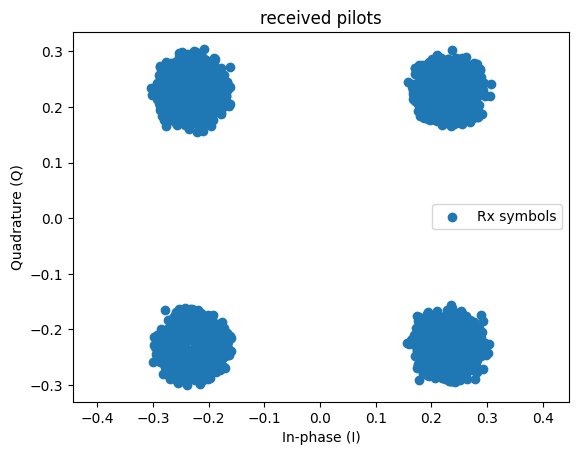

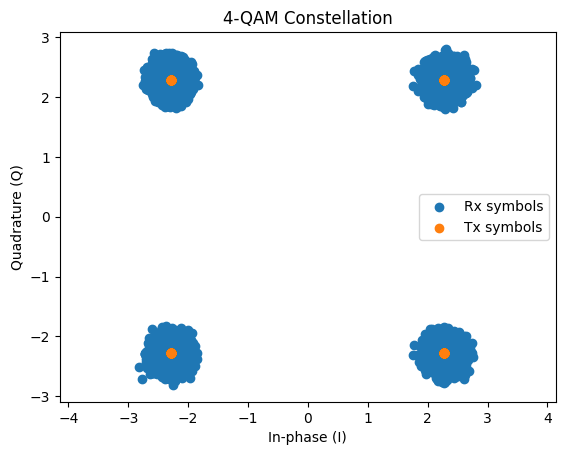

In [24]:
y_combined_freq = wf.ofdm_time_to_freq(stripe_data[0])
x_combined_freq = wf.ofdm_time_to_freq(ofdm_time)
xsubc = wf.extract_subcarriers(x_combined_freq)

# sanity check
rx_subc = wf.extract_subcarriers(y_combined_freq)
# look at a few carriers around pilots and data
wf.plot_constellation(rx_subc[0, wf.pilot_indices], title="received pilots")

# channel estimation
subc = wf.extract_subcarriers(y_combined_freq)
H_est = wf.channel_estimate_ls(subc)

# equalization
eq_subc = wf.equalize_one_tap(subc, H_est)

nmse = np.sum(np.abs(eq_subc - xsubc) ** 2) / np.sum(np.abs(xsubc) ** 2)

# Demap data carriers and rebuild stream
data_symbols = wf.demap_data_from_grid(eq_subc).flatten()  # these are the received QAM symbols

y_qam = data_symbols

# quick sanity
assert y_qam.shape[0] == qam.shape[0], f"Lengths differ: rx {y_qam.shape[0]} tx {qam.shape[0]}"

wf.plot_constellation(eq_subc, symbols_tx=xsubc)

y_bits = wf.qam_to_bits(y_qam)

ber = wf.compute_ber(bits, y_bits)
print(f"NMSE: {10 * np.log10(nmse)}")
print(f"BER: {ber}")